#  Model Training


## Generate data

In [1]:
import agama
import torch 
import numpy as np
from astropy import units as u

from sbi.utils import BoxUniform
from sbi.inference import SNLE, simulate_for_sbi, prepare_for_sbi

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
import pickle

from python_scripts.galaxy_generation import generate_galaxy_multiple
from python_scripts.prior_generation import generate_prior

In [2]:
# set agama unit to be in Msun, kpc, km/s
agama.setUnits(mass=1 * u.Msun, length=1*u.kpc, velocity=1 * u.km /u.s)

## Training

In [3]:
agama.setRandomSeed(13)
torch.manual_seed(13)
np.random.seed(13)


### Generating data

In [29]:
prior = generate_prior()
simulator_sbi, prior_sbi = prepare_for_sbi(generate_galaxy_multiple, prior)

In [13]:
#. Generate Training Data
theta_train, x_train = simulate_for_sbi(
    simulator_sbi, prior_sbi, num_simulations=1000, num_workers=1
)
x_train = x_train.squeeze()

Running 1000 simulations.:   0%|          | 0/1000 [00:00<?, ?it/s]

#### Generating 10000 data then saving to csv

In [7]:
prior = generate_prior()

In [51]:
theta = prior.sample((10000,))
df = pd.DataFrame(np.repeat(theta, 100, axis=0))
df.to_csv("./data/training_theta.csv", index=False, header=False)

In [52]:
x = generate_galaxy_multiple(theta, 100).numpy()
out = x.reshape(x.shape[0] * x.shape[1], x.shape[2])
df = pd.DataFrame(out)

df.to_csv("./data/training_x.csv", index=False, header=False)

#### Generating 10k galaxies, 10 stars

In [16]:
df = np.array(pd.read_csv("./data/training_x(100).csv", header=None))
df= df.reshape((10000, 100, 6))
df = df[:, :10, :]
df = pd.DataFrame(df.reshape((100000, 6)))
df.to_csv("./data/training_x(10).csv", index=False, header=False)

In [18]:
df = np.array(pd.read_csv("./data/training_theta(100).csv", header=None))
df= df.reshape((10000, 100, 4))
df = df[:, :10, :]
df = pd.DataFrame(df.reshape((100000, 4)))
df.to_csv("./data/training_theta(10).csv", index=False, header=False)


#### Poisson distribution

In [70]:
prior = generate_prior()
thetas = prior.sample((10000,))

n_list = []
output_x = []

for row in thetas:
    r = row.reshape((1,4))
    n = np.random.poisson(100)
    n_list.append(n)
    
    xs = generate_galaxy_multiple(r, n_stars=n)
    output_x.append(xs)
    
theta = torch.repeat_interleave(thetas, torch.tensor(n_list), dim=0)
x = torch.cat(output_x, dim=1).squeeze()
    



In [71]:
pd.DataFrame(theta).to_csv("./data/training_theta(poisson).csv", header=False, index=False)
pd.DataFrame(x).to_csv("./data/training_x(poisson).csv", header=False, index=False)

#### Test samples

In [72]:
prior = generate_prior()
thetas = prior.sample((1000,))

n_list = []
output_x = []

for row in thetas:
    r = row.reshape((1,4))
    n = np.random.poisson(100)
    n_list.append(n)
    
    xs = generate_galaxy_multiple(r, n_stars=n)
    output_x.append(xs)
    
theta = torch.repeat_interleave(thetas, torch.tensor(n_list), dim=0)
x = torch.cat(output_x, dim=1).squeeze()
    
pd.DataFrame(theta).to_csv("./data/test_theta.csv", header=False, index=False)
pd.DataFrame(x).to_csv("./data/test_x.csv", header=False, index=False)


### Train the model

#### Single star per galaxy

In [36]:
theta_train = torch.from_numpy(np.array(pd.read_csv("./data/training_theta(100).csv", header=None))).float()
x_train = torch.from_numpy(np.array(pd.read_csv("./data/training_x(100).csv", header=None))).float()

In [40]:
torch.set_num_threads(4)
prior_sbi = generate_prior()
inference = SNLE(prior=prior_sbi)
inference.append_simulations(theta_train, x_train)
arg = {
        "training_batch_size": 512,
        "learning_rate": 0.01,
        "validation_fraction": 0.1,
        "stop_after_epochs": 10,
        "max_num_epochs": 2^31 - 1,
        "clip_max_norm": 5.0,
        "resume_training": False,
        "discard_prior_samples": False,
        "retrain_from_scratch": False,
        "show_train_summary": True,
        "dataloader_kwargs": None
}

likelihood_estimator = inference.train(**arg)

 Training neural network. Epochs trained: 2

KeyboardInterrupt: 

In [16]:
inference._summary["best_validation_log_prob"]

[-8.152990356445313]

### Pickle

In [ ]:


posterior = inference.build_posterior(likelihood_estimator, mcmc_method="slice_np_vectorized")

with open("./model/posterior.pkl", "wb") as handle:
    pickle.dump(posterior, handle)


In [52]:
with open("./model/likelihood_estimator.pkl", "wb") as handle:
    pickle.dump(likelihood_estimator, handle)

In [ ]:

with open('./model/posterior.pkl', 'rb') as file:
    # Load the object from the file
    posterior = pickle.load(file)

### Hyperparameter tuning

In [7]:
import optuna

In [ ]:
def objective(trial):
        
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    training_batch_size = trial.suggest_categorical("training_batch_size", [32, 64, 128, 256, 512, 1024, 2048])
    
    theta_train = torch.from_numpy(np.array(pd.read_csv("./data/training_theta.csv", header=None))).float()
    x_train = torch.from_numpy(np.array(pd.read_csv("./data/training_x.csv", header=None))).float() 
    
    prior_sbi = generate_prior()
    inference = SNLE(prior=prior_sbi)
    inference.append_simulations(theta_train, x_train)
    
    likelihood_estimator = inference.train(learning_rate = learning_rate,
                                           training_batch_size = training_batch_size,
                                           stop_after_epochs = 10,
    )
    
    return inference._summary["best_validation_log_prob"][0]

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=2)

import pickle
with open("./model/tune.pkl", "wb") as handle:
    pickle.dump(study, handle)
    
print(study.best_params)


[I 2026-05-19 09:25:52,851] A new study created in memory with name: no-name-ca9aa964-5828-4182-bfd7-5129bfa15e72


 Training neural network. Epochs trained: 109

[I 2026-05-19 09:41:45,440] Trial 0 finished with value: -7.2913370289522055 and parameters: {'learning_rate': 0.00046936482650969613, 'training_batch_size': 425, 'stop_after_epochs': 20}. Best is trial 0 with value: -7.2913370289522055.


 Training neural network. Epochs trained: 160110 epochs.

[I 2026-05-19 10:04:58,854] Trial 1 finished with value: -8.581448269873551 and parameters: {'learning_rate': 6.218574263473771e-05, 'training_batch_size': 388, 'stop_after_epochs': 20}. Best is trial 0 with value: -7.2913370289522055.


 Neural network successfully converged after 161 epochs.

In [ ]:
study.best_params

{'learning_rate': 0.00046936482650969613,
 'training_batch_size': 425,
 'stop_after_epochs': 20}

## MCMC

In [73]:
from sbi.inference import likelihood_estimator_based_potential, MCMCPosterior


In [74]:

def generate_samples(x_o, likelihood_estimator, prior, n_samples):
    """
    generate sample for single observed x (perhaps with multiple stars, but generated from same theta)

    - x_o: observed (single star) universe
    - n_samples: number of samples to generate
    """
    potential_fn, parameter_transform = likelihood_estimator_based_potential(
    likelihood_estimator, prior, x_o
)
    posterior = MCMCPosterior(
    potential_fn, proposal=prior, 
    theta_transform=parameter_transform, 
    warmup_steps=200,
    num_chains=20,
    num_workers= 1,
    method = "slice_np_vctorized"
    )

    samples = posterior.sample((n_samples,))

    return samples



In [8]:
with open('./model/likelihood_estimator.pkl', 'rb') as file:
    # Load the object from the file
    likelihood_estimator = pickle.load(file)

In [10]:
prior = generate_prior()

test_theta = prior.sample((3,))
test_x = generate_galaxy_multiple(test_theta).squeeze()


In [24]:
samples = np.array([generate_samples(x_o, likelihood_estimator, prior, 1000) for x_o in test_x])

KeyboardInterrupt: 

In [14]:
print(np.median(samples, axis=1))
print(test_theta)


[[ 6.445016   -0.22769523  0.6208264   0.6603873 ]
 [ 5.556221    0.09733844 -0.09867397  0.6658144 ]
 [ 6.936132   -0.7049843   0.80761826  0.5005387 ]]
tensor([[ 5.2755, -0.1851,  1.4317,  0.2121],
        [ 5.0459,  0.0261, -0.3046,  0.8906],
        [ 7.9577, -0.6642, -0.7510,  0.5403]])


## Evaluating model performance

In [20]:
def evaluate_model(theta, medians):
    for i in range(4):
        mse = mean_squared_error(theta[:,i], medians[:,i])
        r2 = r2_score(theta[:,i], medians[:,i])
        print(f"MSE for {i}th entry is {mse}")
        print(f"R^2 for {i}th entry is {r2}")
        print()


## Graphing Performance of model

x and y are supposed to be MCMC chains

NameError: name 'x' is not defined

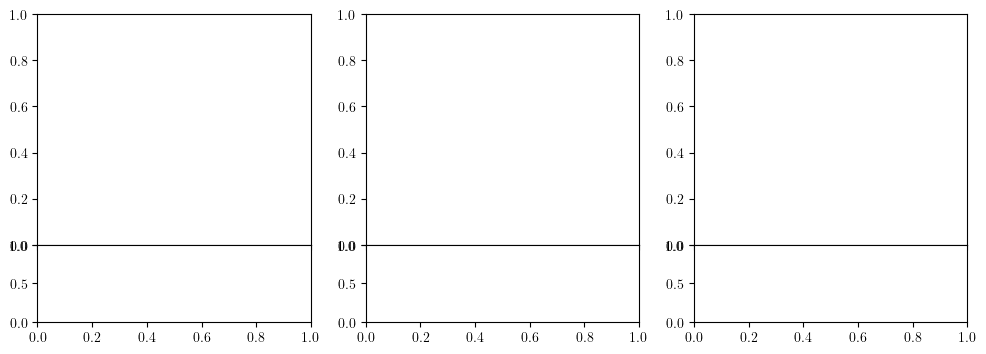

In [ ]:
import matplotlib.pyplot as plt


plt.rcParams["text.usetex"] = True

fig, axs = plt.subplots(2,3, figsize=(12,4), sharex="col", gridspec_kw={'hspace': 0,
                                                                        'height_ratios': [3, 1]})

x_titles = ["$\log_{10}(\\rho _0)$", "$\log_{10}(r_s)$", "$\gamma$"]
y_titles = ["$\log_{10}(\hat{\\rho _0})$", "$\log_{10}(\hat{r_s})$", "$\hat \gamma$"]

dom_min = [5, -1, -1, 0.2]
dom_max = [8, 0.7, 2, 1]

# Top plots
for i, ax in enumerate(axs[0, :]):
    index = np.argsort(x[:,i])
    truth = x[:,i][index]
    
    # Median
    sim_median = y[2][:,i][index]
    ax.plot(truth, sim_median, color="blue", label="Median")

    # 68-84
    sim_16 = y[1][:,i][index]
    sim_84 = y[3][:,i][index]
    ax.fill_between(truth, sim_16, sim_84, color=(133 / 256,133/256,247/256, 0.8), label="Mid. 68\%")
    

    # 2.5-97.5
    sim_2_5 = y[0][:,i][index]
    sim_97_5 = y[4][:,i][index]
    ax.fill_between(truth, sim_2_5, sim_97_5, color=(133 / 256,133/256,247/256, 0.5), label="Mid. 95\%")

    # Truth
    true_x = [dom_min[i], dom_max[i]]

    ax.plot(true_x, true_x, color="red", linestyle = "--", label="Truth")

    # ax.set_xlabel(x_titles[i])
    ax.set_ylabel(y_titles[i])
    
    ax.minorticks_on()
    ax.grid(True)

# bottom plots
bottom_y_titles = ["$\Delta \log_{10}(\\rho _0)$", "$\Delta \log_{10}(r_s)$", "$\Delta \gamma$"]
for i, ax in enumerate(axs[1, :]):
    index = np.argsort(x[:,i])
    truth = x[:,i][index]
    # Median
    sim_median = y[2][:,i][index] - truth
    ax.plot(truth, sim_median, color="blue", label="Median")

    # 68-84
    sim_16 = y[1][:,i][index] - truth
    sim_84 = y[3][:,i][index] - truth
    ax.fill_between(truth, sim_16, sim_84, color=(133 / 256,133/256,247/256, 0.8), label="Mid. 68\%")
    

    # 2.5-97.5
    sim_2_5 = y[0][:,i][index] - truth
    sim_97_5 = y[4][:,i][index] - truth
    ax.fill_between(truth, sim_2_5, sim_97_5, color=(133 / 256,133/256,247/256, 0.5), label="Mid. 95\%")

    # Truth
    true_x = [dom_min[i], dom_max[i]]
    true_y = [0,0]

    ax.plot(true_x, true_y, color="red", linestyle = "--", label="Truth")

    ax.set_xlabel(x_titles[i])
    ax.set_ylabel(bottom_y_titles[i])
    
    ax.minorticks_on()
    ax.grid(True)



fig.suptitle("Truth v. Predicted DM profile parameters", y=1.02)

handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98)

)


plt.tight_layout()
plt.show()